# NSE and Reliance

In [39]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [40]:
end = dt.datetime.today()
start = end - dt.timedelta(days=365)
df = yf.download(['^NSEI','RELIANCE.NS'], start, end,auto_adjust=True)['Close']
df.rename(columns ={'RELIANCE.NS':'reliance','^NSEI':'nse'},inplace=True)
returns = df.pct_change().dropna()
x = returns['nse']
y = returns['reliance']

# Model
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

[*********************100%***********************]  2 of 2 completed

                            OLS Regression Results                            
Dep. Variable:               reliance   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     201.6
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.02e-33
Time:                        12:03:10   Log-Likelihood:                 796.47
No. Observations:                 245   AIC:                            -1589.
Df Residuals:                     243   BIC:                            -1582.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.886      0.3

Text(0.5, 1.0, 'Simple Linear Regression')

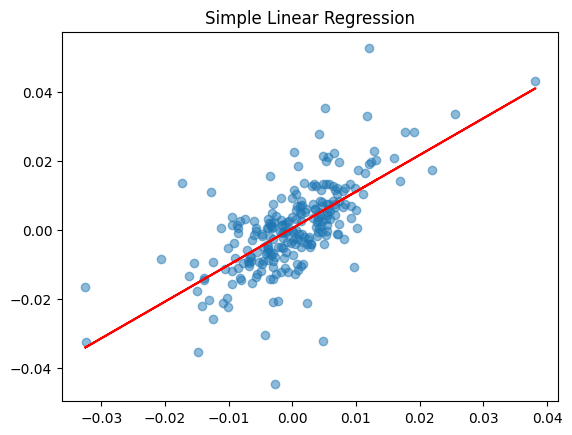

In [41]:
plt.scatter(returns['nse'], returns['reliance'],alpha=0.5,label = 'Dailyline')
plt.plot(returns['nse'],model.fittedvalues,color='red',label = 'Regression line')
plt.title('Simple Linear Regression')